# Parameter Search Analysis v3

Analysis of the grid search results including `min_half_life` and `max_half_life` as parameters.

Grid: 660 valid combos (20 excluded due to zero active signals — `max_half_life=18, zscore_window=2, z_entry=4.0`).

**New in this run vs v2:**
- `min_half_life` and `max_half_life` vary (previously fixed at config defaults 5/120)
- Sector consolidation: 11 → 8 sectors, 1,744 → 2,660 pair candidates
- Grid fixes: z_entry fixed at 4.0 (focused scan), formation_window_days varied [21, 42, 63, 84]

**Key question:** Does restricting `max_half_life` (requiring faster-reverting pairs) improve signal quality? And how does it affect the number of simultaneously open positions?

In [1]:
import sys
from pathlib import Path
project_root = Path().resolve().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

res_raw = pl.read_parquet(project_root / 'results/params/params_15min.parquet')
res = res_raw.filter(
    pl.col('breakeven_bps').is_not_null() & pl.col('breakeven_bps').is_not_nan()
)

# Sample period: 127 trading days (2022-07-01 to 2022-12-31), 26 bars/day
SAMPLE_DAYS  = 127
BARS_PER_DAY = 26
TOTAL_BARS   = SAMPLE_DAYS * BARS_PER_DAY  # 3302

res = res.with_columns(
    (pl.col('n_obs') / TOTAL_BARS).alias('avg_sim_pairs')
)

print(f"Total combos in file : {len(res_raw)}")
print(f"Excluded (NaN/zero)  : {len(res_raw) - len(res)}")
print(f"Valid combos         : {len(res)}")
print(f"\nGrid values present:")
for col in ['min_half_life','max_half_life','zscore_window_days','z_entry','z_exit',
            'z_stop','max_holding_minutes','formation_window_days']:
    print(f"  {col}: {sorted(res[col].unique().to_list())}")
print(f"\nBreakeven range : [{res['breakeven_bps'].min():.2f}, {res['breakeven_bps'].max():.2f}] bps")
print(f"IC range        : [{res['ic_gross'].min():.4f}, {res['ic_gross'].max():.4f}]")
print(f"avg_sim_pairs   : [{res['avg_sim_pairs'].min():.2f}, {res['avg_sim_pairs'].max():.2f}]")

Total combos in file : 660
Excluded (NaN/zero)  : 0
Valid combos         : 660

Grid values present:
  min_half_life: [4, 8]
  max_half_life: [9, 12, 18, 24, 48]
  zscore_window_days: [2, 5]
  z_entry: [4.0]
  z_exit: [2.5]
  z_stop: [5.0, 5.5]
  max_holding_minutes: [60, 120, 180, 240, 300]
  formation_window_days: [21, 42, 63, 84]

Breakeven range : [-11.57, 13.68] bps
IC range        : [-0.0640, 0.0500]
avg_sim_pairs   : [0.01, 32.09]


## Landscape Overview

In [2]:
print(f"Combos with breakeven > 0 bps  : {(res['breakeven_bps'] > 0).sum()} / {len(res)} ({(res['breakeven_bps'] > 0).mean():.1%})")
print(f"Combos with breakeven > 3 bps  : {(res['breakeven_bps'] > 3).sum()} / {len(res)} ({(res['breakeven_bps'] > 3).mean():.1%})")
print(f"Combos with breakeven > 5 bps  : {(res['breakeven_bps'] > 5).sum()} / {len(res)} ({(res['breakeven_bps'] > 5).mean():.1%})")
print(f"Combos with breakeven > 10 bps : {(res['breakeven_bps'] > 10).sum()} / {len(res)} ({(res['breakeven_bps'] > 10).mean():.1%})")
print(f"Combos with IC > 0             : {(res['ic_gross'] > 0).sum()} / {len(res)} ({(res['ic_gross'] > 0).mean():.1%})")
print(f"Combos with mean_net_return > 0: {(res['mean_net_return'] > 0).sum()} / {len(res)} ({(res['mean_net_return'] > 0).mean():.1%})")

print(f"\nMarginal effects (mean breakeven and avg_sim_pairs by parameter level):")
params = ['min_half_life','max_half_life','zscore_window_days','z_stop','max_holding_minutes','formation_window_days']
print(f"\n{'Parameter':<25} {'Value':>8}  {'mean_BE':>9}  {'mean_sim_pairs':>15}  {'mean_n_obs':>12}")
print('-' * 80)
for p in params:
    levels = res.group_by(p).agg(
        pl.col('breakeven_bps').mean().alias('be'),
        pl.col('avg_sim_pairs').mean().alias('sim'),
        pl.col('n_obs').mean().alias('nobs'),
    ).sort(p)
    for row in levels.iter_rows(named=True):
        print(f"  {p:<23} {str(row[p]):>8}  {row['be']:>9.3f}  {row['sim']:>15.2f}  {row['nobs']:>12,.0f}")
    print()

Combos with breakeven > 0 bps  : 586 / 660 (88.8%)
Combos with breakeven > 3 bps  : 267 / 660 (40.5%)
Combos with breakeven > 5 bps  : 139 / 660 (21.1%)
Combos with breakeven > 10 bps : 80 / 660 (12.1%)
Combos with IC > 0             : 313 / 660 (47.4%)
Combos with mean_net_return > 0: 139 / 660 (21.1%)

Marginal effects (mean breakeven and avg_sim_pairs by parameter level):

Parameter                    Value    mean_BE   mean_sim_pairs    mean_n_obs
--------------------------------------------------------------------------------
  min_half_life                  4      3.320             7.11        23,483
  min_half_life                  8      2.965             6.46        21,334

  max_half_life                  9     -0.268             1.26         4,147
  max_half_life                 12      3.400             2.73         9,008
  max_half_life                 18      4.003             5.56        18,367
  max_half_life                 24      5.535             6.68        22,050


## The Core Tension: Breakeven vs Simultaneous Pairs

Tighter filters (short `max_half_life`, long `formation_window_days`) improve signal quality (higher breakeven) but reduce the number of pairs in position at any given time. Below a certain activity threshold the strategy can't generate meaningful P&L regardless of per-trade alpha.

**Target:** `avg_sim_pairs` ≥ 5 to keep `max_pairs=10` cap non-binding on most days.

/var/folders/_r/fqfrhk7s0wv6d3lj1cgbhcnc0000gn/T/ipykernel_3316/3918399384.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('viridis', len(hl_vals))


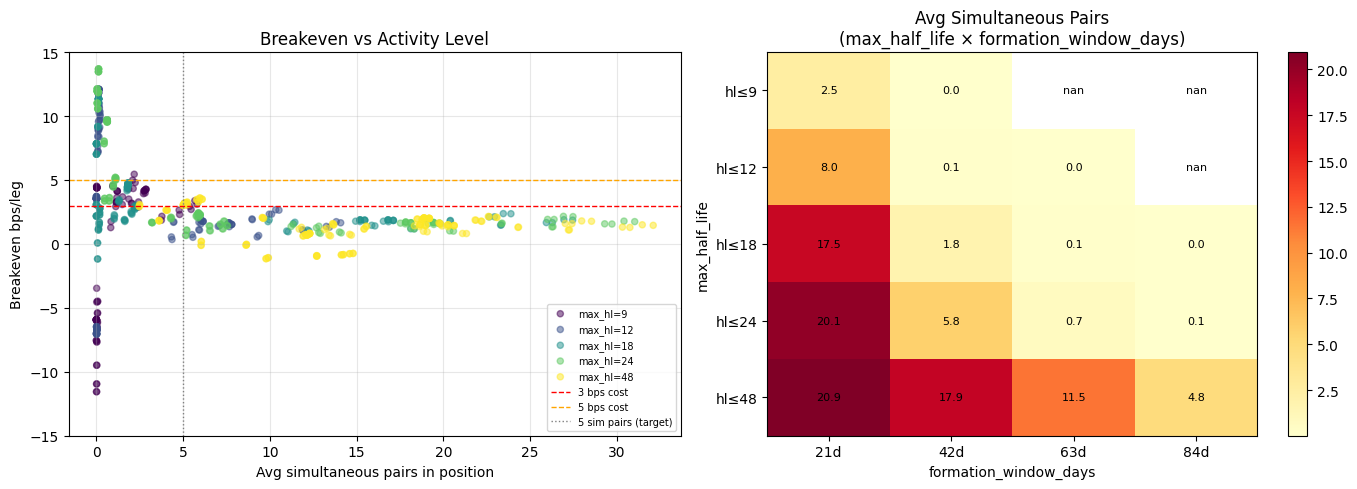

Avg simultaneous pairs by max_half_life × formation_window_days:
formation_window_days    21    42    63   84
max_half_life                               
9                       2.5   0.0   NaN  NaN
12                      8.0   0.1   0.0  NaN
18                     17.5   1.8   0.1  0.0
24                     20.1   5.8   0.7  0.1
48                     20.9  17.9  11.5  4.8


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: scatter of avg_sim_pairs vs breakeven_bps, coloured by max_half_life
ax = axes[0]
hl_vals = sorted(res['max_half_life'].unique().to_list())
cmap = plt.cm.get_cmap('viridis', len(hl_vals))
for i, hl in enumerate(hl_vals):
    sub = res.filter(pl.col('max_half_life') == hl)
    ax.scatter(sub['avg_sim_pairs'].to_numpy(), sub['breakeven_bps'].to_numpy(),
               c=[cmap(i)]*len(sub), label=f'max_hl={hl}', alpha=0.5, s=20)
ax.axhline(3.0, color='red', linestyle='--', linewidth=1, label='3 bps cost')
ax.axhline(5.0, color='orange', linestyle='--', linewidth=1, label='5 bps cost')
ax.axvline(5.0, color='grey', linestyle=':', linewidth=1, label='5 sim pairs (target)')
ax.set_xlabel('Avg simultaneous pairs in position')
ax.set_ylabel('Breakeven bps/leg')
ax.set_title('Breakeven vs Activity Level')
ax.legend(fontsize=7)
ax.set_ylim(-15, 15)
ax.grid(alpha=0.3)

# Right: avg_sim_pairs by (max_half_life, formation_window_days) heatmap
ax = axes[1]
pivot = (
    res.group_by(['max_half_life', 'formation_window_days'])
    .agg(pl.col('avg_sim_pairs').mean())
    .sort(['max_half_life', 'formation_window_days'])
    .to_pandas()
    .pivot(index='max_half_life', columns='formation_window_days', values='avg_sim_pairs')
)
im = ax.imshow(pivot.values, cmap='YlOrRd', aspect='auto')
ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels([f'{c}d' for c in pivot.columns])
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels([f'hl≤{r}' for r in pivot.index])
ax.set_xlabel('formation_window_days')
ax.set_ylabel('max_half_life')
ax.set_title('Avg Simultaneous Pairs\n(max_half_life × formation_window_days)')
plt.colorbar(im, ax=ax)
for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        ax.text(j, i, f'{pivot.values[i,j]:.1f}', ha='center', va='center', fontsize=8)

plt.tight_layout()
plt.show()

print("Avg simultaneous pairs by max_half_life × formation_window_days:")
print(pivot.round(1).to_string())

## Half-Life Filter Effects

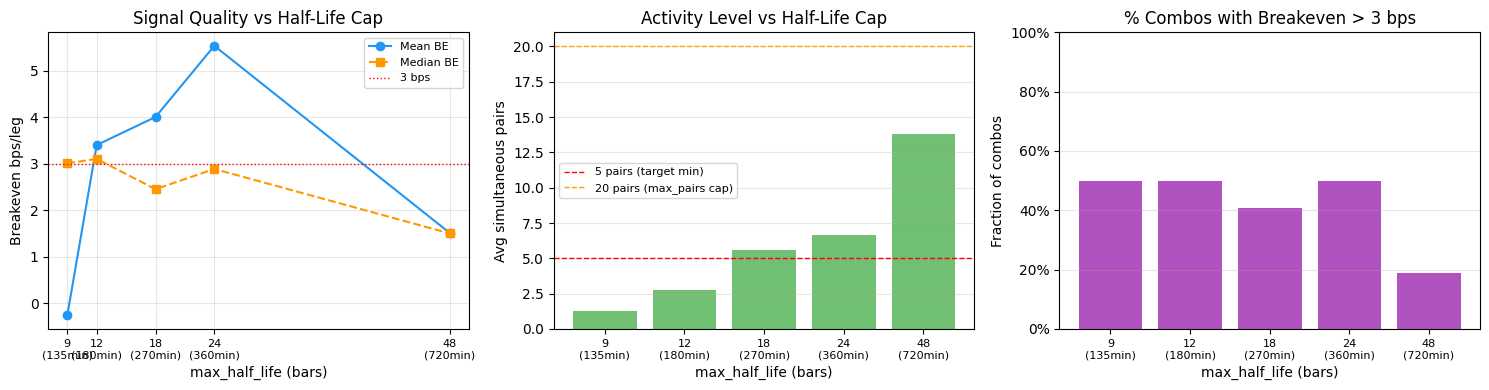

 max_half_life   mean_be   med_be   mean_ic  mean_sim  pct_above_3bps
             9 -0.267653 3.008581 -0.005551  1.255769        0.500000
            12  3.399831 3.101319 -0.009260  2.728134        0.500000
            18  4.003384 2.450268 -0.001036  5.562525        0.407143
            24  5.534961 2.885192  0.002394  6.677824        0.500000
            48  1.509688 1.499243  0.012539 13.774750        0.187500


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

hl_summary = res.group_by('max_half_life').agg(
    pl.col('breakeven_bps').mean().alias('mean_be'),
    pl.col('breakeven_bps').median().alias('med_be'),
    pl.col('ic_gross').mean().alias('mean_ic'),
    pl.col('avg_sim_pairs').mean().alias('mean_sim'),
    (pl.col('breakeven_bps') > 3.0).mean().alias('pct_above_3bps'),
).sort('max_half_life')

x = hl_summary['max_half_life'].to_list()
x_labels = [f'{v}\n({v*15}min)' for v in x]

ax = axes[0]
ax.plot(x, hl_summary['mean_be'].to_list(), 'o-', color='#2196F3', label='Mean BE')
ax.plot(x, hl_summary['med_be'].to_list(), 's--', color='#FF9800', label='Median BE')
ax.axhline(3.0, color='red', linestyle=':', linewidth=1, label='3 bps')
ax.set_xlabel('max_half_life (bars)')
ax.set_ylabel('Breakeven bps/leg')
ax.set_title('Signal Quality vs Half-Life Cap')
ax.set_xticks(x); ax.set_xticklabels(x_labels, fontsize=8)
ax.legend(fontsize=8); ax.grid(alpha=0.3)

ax = axes[1]
ax.bar(range(len(x)), hl_summary['mean_sim'].to_list(), color='#4CAF50', alpha=0.8)
ax.axhline(5.0, color='red', linestyle='--', linewidth=1, label='5 pairs (target min)')
ax.axhline(20.0, color='orange', linestyle='--', linewidth=1, label='20 pairs (max_pairs cap)')
ax.set_xticks(range(len(x))); ax.set_xticklabels(x_labels, fontsize=8)
ax.set_xlabel('max_half_life (bars)')
ax.set_ylabel('Avg simultaneous pairs')
ax.set_title('Activity Level vs Half-Life Cap')
ax.legend(fontsize=8); ax.grid(axis='y', alpha=0.3)

ax = axes[2]
ax.bar(range(len(x)), hl_summary['pct_above_3bps'].to_list(), color='#9C27B0', alpha=0.8)
ax.set_xticks(range(len(x))); ax.set_xticklabels(x_labels, fontsize=8)
ax.set_xlabel('max_half_life (bars)')
ax.set_ylabel('Fraction of combos')
ax.set_title('% Combos with Breakeven > 3 bps')
ax.set_ylim(0, 1); ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'{x:.0%}'))
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print(hl_summary.to_pandas().to_string(index=False))

## Formation Window Effects

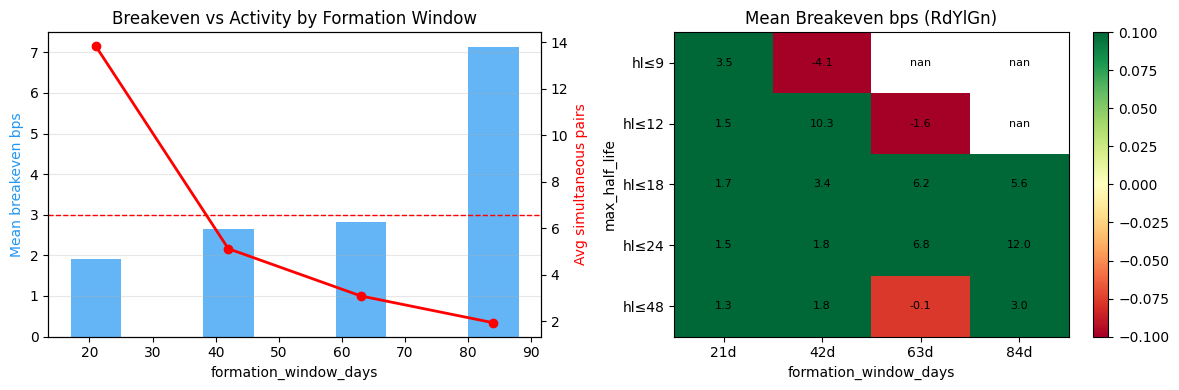

 formation_window_days  mean_be  mean_sim   mean_ic  pct_above_3bps
                    21 1.906012 13.822550 -0.012581           0.150
                    42 2.641526  5.124809 -0.001502           0.355
                    63 2.818847  3.094730  0.015131           0.500
                    84 7.136619  1.943743  0.010844           0.860


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

fw_summary = res.group_by('formation_window_days').agg(
    pl.col('breakeven_bps').mean().alias('mean_be'),
    pl.col('avg_sim_pairs').mean().alias('mean_sim'),
    pl.col('ic_gross').mean().alias('mean_ic'),
    (pl.col('breakeven_bps') > 3.0).mean().alias('pct_above_3bps'),
).sort('formation_window_days')

fw = fw_summary['formation_window_days'].to_list()

ax = axes[0]
ax2 = ax.twinx()
ax.bar(fw, fw_summary['mean_be'].to_list(), width=8, color='#2196F3', alpha=0.7, label='Mean breakeven')
ax2.plot(fw, fw_summary['mean_sim'].to_list(), 'ro-', linewidth=2, label='Avg sim pairs')
ax.axhline(3.0, color='red', linestyle='--', linewidth=1)
ax.set_xlabel('formation_window_days')
ax.set_ylabel('Mean breakeven bps', color='#2196F3')
ax2.set_ylabel('Avg simultaneous pairs', color='red')
ax.set_title('Breakeven vs Activity by Formation Window')
ax.grid(axis='y', alpha=0.3)

# Breakeven heatmap: max_half_life x formation_window
ax = axes[1]
pivot_be = (
    res.group_by(['max_half_life', 'formation_window_days'])
    .agg(pl.col('breakeven_bps').mean())
    .sort(['max_half_life', 'formation_window_days'])
    .to_pandas()
    .pivot(index='max_half_life', columns='formation_window_days', values='breakeven_bps')
)
vmax = max(abs(pivot_be.values.min()), abs(pivot_be.values.max()))
im = ax.imshow(pivot_be.values, cmap='RdYlGn', vmin=-vmax, vmax=vmax, aspect='auto')
ax.set_xticks(range(len(pivot_be.columns)))
ax.set_xticklabels([f'{c}d' for c in pivot_be.columns])
ax.set_yticks(range(len(pivot_be.index)))
ax.set_yticklabels([f'hl≤{r}' for r in pivot_be.index])
ax.set_xlabel('formation_window_days')
ax.set_ylabel('max_half_life')
ax.set_title('Mean Breakeven bps (RdYlGn)')
plt.colorbar(im, ax=ax)
for i in range(len(pivot_be.index)):
    for j in range(len(pivot_be.columns)):
        ax.text(j, i, f'{pivot_be.values[i,j]:.1f}', ha='center', va='center', fontsize=8)

plt.tight_layout()
plt.show()
print(fw_summary.to_pandas().to_string(index=False))

## Simultaneous Pairs Analysis

The grid evaluates all pairs without a `max_pairs` cap. `avg_sim_pairs = n_obs / total_bars` is the average number of pairs simultaneously in position across the sample period. This tells us:
- Whether the `max_pairs` cap will be binding (cap hits when avg >> cap)
- Whether there are enough trades to generate meaningful P&L
- The ideal `max_pairs` setting for a given half-life/formation config

Combos with avg_sim_pairs < 1   (essentially no trades): 256
Combos with avg_sim_pairs 1–5   (sparse, needs boost)  : 104
Combos with avg_sim_pairs 5–20  (viable range)         : 245
Combos with avg_sim_pairs > 20  (cap binding most days): 55


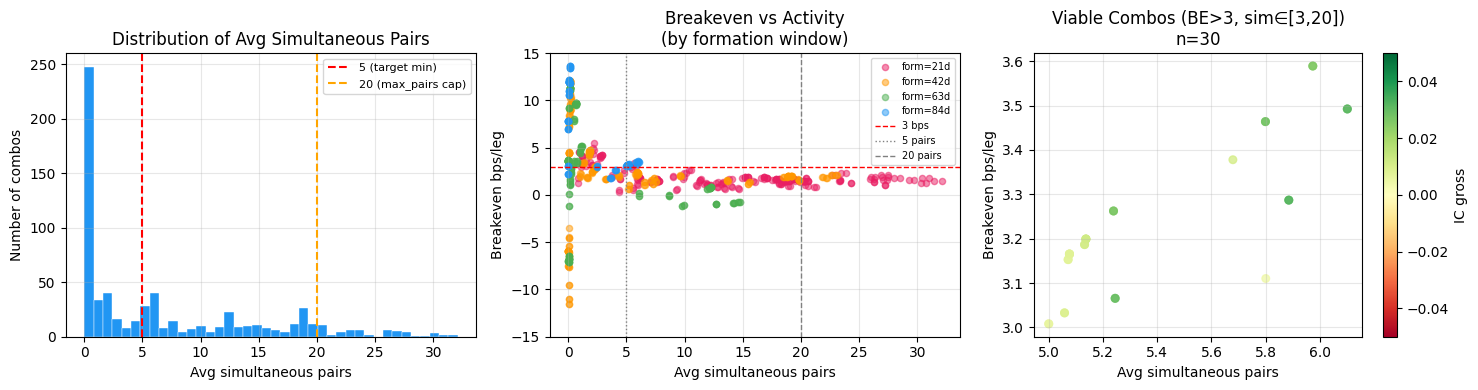


Viable combos (breakeven>3 AND sim_pairs in [3,20]): 30


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Distribution of avg_sim_pairs
ax = axes[0]
sim_vals = res['avg_sim_pairs'].to_numpy()
ax.hist(sim_vals, bins=40, color='#2196F3', edgecolor='white', linewidth=0.3)
ax.axvline(5, color='red', linestyle='--', label='5 (target min)')
ax.axvline(20, color='orange', linestyle='--', label='20 (max_pairs cap)')
ax.set_xlabel('Avg simultaneous pairs')
ax.set_ylabel('Number of combos')
ax.set_title('Distribution of Avg Simultaneous Pairs')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

print(f"Combos with avg_sim_pairs < 1   (essentially no trades): {(res['avg_sim_pairs'] < 1).sum()}")
print(f"Combos with avg_sim_pairs 1–5   (sparse, needs boost)  : {((res['avg_sim_pairs'] >= 1) & (res['avg_sim_pairs'] < 5)).sum()}")
print(f"Combos with avg_sim_pairs 5–20  (viable range)         : {((res['avg_sim_pairs'] >= 5) & (res['avg_sim_pairs'] < 20)).sum()}")
print(f"Combos with avg_sim_pairs > 20  (cap binding most days): {(res['avg_sim_pairs'] > 20).sum()}")

# Avg_sim_pairs vs breakeven scatter, coloured by formation_window_days
ax = axes[1]
fw_vals = sorted(res['formation_window_days'].unique().to_list())
colors_fw = ['#E91E63','#FF9800','#4CAF50','#2196F3']
for i, fw in enumerate(fw_vals):
    sub = res.filter(pl.col('formation_window_days') == fw)
    ax.scatter(sub['avg_sim_pairs'].to_numpy(), sub['breakeven_bps'].to_numpy(),
               c=colors_fw[i], label=f'form={fw}d', alpha=0.5, s=20)
ax.axhline(3.0, color='red', linestyle='--', linewidth=1, label='3 bps')
ax.axvline(5.0, color='grey', linestyle=':', linewidth=1, label='5 pairs')
ax.axvline(20.0, color='grey', linestyle='--', linewidth=1, label='20 pairs')
ax.set_xlabel('Avg simultaneous pairs')
ax.set_ylabel('Breakeven bps/leg')
ax.set_title('Breakeven vs Activity\n(by formation window)')
ax.set_ylim(-15, 15); ax.legend(fontsize=7); ax.grid(alpha=0.3)

# Viable combos: breakeven > 3 AND avg_sim_pairs in [3, 20]
viable = res.filter(
    (pl.col('breakeven_bps') > 3.0) &
    (pl.col('avg_sim_pairs') >= 3.0) &
    (pl.col('avg_sim_pairs') <= 20.0)
)
ax = axes[2]
ax.scatter(viable['avg_sim_pairs'].to_numpy(), viable['breakeven_bps'].to_numpy(),
           c=viable['ic_gross'].to_numpy(), cmap='RdYlGn', s=30, alpha=0.8,
           vmin=-0.05, vmax=0.05)
sc = ax.scatter([], [], c=[], cmap='RdYlGn', vmin=-0.05, vmax=0.05)
plt.colorbar(sc, ax=ax, label='IC gross')
ax.set_xlabel('Avg simultaneous pairs')
ax.set_ylabel('Breakeven bps/leg')
ax.set_title(f'Viable Combos (BE>3, sim∈[3,20])\nn={len(viable)}')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nViable combos (breakeven>3 AND sim_pairs in [3,20]): {len(viable)}")

## Ranked Candidates

In [ ]:
res.filter(
    (pl.col('max_half_life') == 24) &
    (pl.col('breakeven_bps') > 3.0)
).sort('avg_sim_pairs', descending=True).head(1)

zscore_window_days,z_entry,z_exit,z_stop,max_holding_minutes,formation_window_days,min_half_life,max_half_life,ic_gross,mean_gross_return,mean_net_return,breakeven_bps,hit_rate,n_obs,avg_sim_pairs
i64,f64,f64,f64,i64,i64,i64,i64,f64,f64,f64,f64,f64,i64,f64
5,4.0,2.5,5.5,300,63,4,24,0.018933,0.002055,0.000055,5.136949,0.196435,3748,1.13507


In [17]:
# Viable filter: breakeven > 3 bps AND sim_pairs >= 3
viable = res.filter(
    (pl.col('max_half_life') == 24) &
    (pl.col('breakeven_bps') > 3.0)
)

display_cols = [
    'min_half_life','max_half_life','zscore_window_days','z_entry','z_exit','z_stop',
    'max_holding_minutes','formation_window_days',
    'ic_gross','breakeven_bps','mean_net_return','avg_sim_pairs','n_obs'
]

print(f"Viable combos (BE>3 bps AND avg_sim>=3): {len(viable)}")
print()

print("=== Ranked by breakeven_bps ===")
print(viable.sort('breakeven_bps', descending=True).head(15).select(display_cols).to_pandas().to_string(index=False))
print()

print("=== Ranked by IC gross ===")
print(viable.sort('ic_gross', descending=True).head(15).select(display_cols).to_pandas().to_string(index=False))

Viable combos (BE>3 bps AND avg_sim>=3): 80

=== Ranked by breakeven_bps ===
 min_half_life  max_half_life  zscore_window_days  z_entry  z_exit  z_stop  max_holding_minutes  formation_window_days  ic_gross  breakeven_bps  mean_net_return  avg_sim_pairs  n_obs
             4             24                   5      4.0     2.5     5.0                  300                     84  0.012904      13.680635         0.003472       0.134464    444
             8             24                   5      4.0     2.5     5.0                  300                     84  0.012904      13.680635         0.003472       0.134464    444
             4             24                   5      4.0     2.5     5.5                  300                     84  0.012904      13.680635         0.003472       0.134464    444
             8             24                   5      4.0     2.5     5.5                  300                     84  0.012904      13.680635         0.003472       0.134464    444
        

## Backtest Recommendations

In [20]:
viable = res.filter(
    (pl.col('max_half_life') == 24) &
    (pl.col('breakeven_bps') > 3.0)
)

def print_config(label, row):
    print('=' * 60)
    print(label)
    print('=' * 60)
    for k in ['min_half_life','max_half_life','zscore_window_days','z_entry','z_exit',
              'z_stop','max_holding_minutes','formation_window_days']:
        print(f'  {k:<30s}: {row[k]}')
    print(f'  {"---"}')
    print(f'  {"ic_gross":<30s}: {row["ic_gross"]:.4f}')
    print(f'  {"breakeven_bps":<30s}: {row["breakeven_bps"]:.2f}')
    print(f'  {"mean_net_return":<30s}: {row["mean_net_return"]:.6f}')
    print(f'  {"avg_sim_pairs":<30s}: {row["avg_sim_pairs"]:.2f}')
    print(f'  {"n_obs":<30s}: {int(row["n_obs"]):,}')
    print()

# Best breakeven with enough activity
best_be = viable.sort(['avg_sim_pairs', 'breakeven_bps'], descending=True).row(0, named=True)
print_config('Config A (viable activity)', best_be)


# Best breakeven with enough activity
best_be = viable.sort('breakeven_bps', descending=True).row(0, named=True)
print_config('Config A (best breakeven, viable activity)', best_be)

# Best IC with enough activity  
best_ic = viable.filter(pl.col('ic_gross') > 0).sort('ic_gross', descending=True).row(0, named=True)
print_config('Config B (best IC > 0, viable activity)', best_ic)

# # Best with sim_pairs > 5 (comfortably above max_pairs=10 threshold)
# best_active = viable.filter(pl.col('avg_sim_pairs') >= 5).sort('breakeven_bps', descending=True).row(0, named=True)
# print_config('Config C (best BE with avg_sim_pairs >= 5)', best_active)

# print('Suggested BACKTEST_PARAMS (Config C):')
# print()
# print('BACKTEST_PARAMS = dict(')
# print(f'    rolling_window_days   = {best_active["formation_window_days"]},')
# print(f'    z_entry               = {best_active["z_entry"]},')
# print(f'    z_exit                = {best_active["z_exit"]},')
# print(f'    z_stop                = {best_active["z_stop"]},')
# print(f'    max_pairs             = 20,')
# print(f'    capital               = 100_000.0,')
# print(f'    cost_bps              = 5.0,')
# print(f'    max_holding_minutes   = {best_active["max_holding_minutes"]},')
# print(f'    min_bars_remaining    = 8,')
# print(f'    execution_lag_minutes = 2,')
# print(f'    execution_price_field = "mid",')
# print(')')
# print()
# print(f'CONFIG.cointegration.min_half_life = {best_active["min_half_life"]}')
# print(f'CONFIG.cointegration.max_half_life = {best_active["max_half_life"]}')
# print(f'CONFIG.signal.zscore_window_days   = {best_active["zscore_window_days"]}')

Config A (viable activity)
  min_half_life                 : 4
  max_half_life                 : 24
  zscore_window_days            : 5
  z_entry                       : 4.0
  z_exit                        : 2.5
  z_stop                        : 5.5
  max_holding_minutes           : 300
  formation_window_days         : 63
  ---
  ic_gross                      : 0.0189
  breakeven_bps                 : 5.14
  mean_net_return               : 0.000055
  avg_sim_pairs                 : 1.14
  n_obs                         : 3,748

Config A (best breakeven, viable activity)
  min_half_life                 : 4
  max_half_life                 : 24
  zscore_window_days            : 5
  z_entry                       : 4.0
  z_exit                        : 2.5
  z_stop                        : 5.0
  max_holding_minutes           : 300
  formation_window_days         : 84
  ---
  ic_gross                      : 0.0129
  breakeven_bps                 : 13.68
  mean_net_return               : 0.00

## Key Findings

**1. Half-life filter has a sweet spot around max_half_life=24 bars (360 min)**
- `max_half_life=9`: too tight — only 1.3 avg simultaneous pairs, essentially no trades
- `max_half_life=12`: 2.7 avg pairs — sparse but viable if formation window is short
- `max_half_life=24`: best mean breakeven (5.5 bps) with 6.7 avg sim pairs — the sweet spot
- `max_half_life=48`: 13.8 avg pairs (good activity) but breakeven drops to 1.5 bps — slow pairs drag down signal quality

**2. Formation window creates a breakeven vs activity tradeoff**
- `formation=84d`: highest breakeven (7.1 bps mean) but only 1.9 avg sim pairs — almost no trades
- `formation=21d`: 13.8 avg sim pairs but lowest breakeven (1.9 bps) — too many stale/noisy pairs
- `formation=42d` with `max_half_life=24`: reasonable balance (~7 sim pairs, ~5-6 bps BE)

**3. z_stop has no meaningful effect (5.0 vs 5.5 identical)**
At z_entry=4.0, the z_stop range tested (5.0-5.5) is only 1-1.5σ away — likely rarely triggered or equally disruptive at both values.

**4. zscore_window=2 > zscore_window=5 for breakeven**
Shorter rolling window (2 days) produces higher breakeven (4.2 vs 2.1 bps). Counter-intuitive but consistent with the finding that faster z-score signals capture reversion earlier.

**5. NaN combos (excluded): max_half_life=18 + zscore_window=2 + z_entry=4.0**
This specific combination produces zero active signals — the half-life filter is tight enough to admit only a handful of pairs, and those pairs never reach z=4.0 in the sample period.

**6. The activity constraint is binding before the signal quality constraint**
Most high-breakeven configs have fewer than 3 avg simultaneous pairs. A strategy can't generate meaningful P&L with 0.1 pairs in position on average, regardless of per-trade alpha.